In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix,classification_report
from sklearn.preprocessing import LabelEncoder
import joblib

In [3]:
data = pd.read_csv("/content/Churn data cleaned.csv",header=0)

In [4]:
pd.set_option('display.max_columns', None) #for seeing full column
display(data.head())

,Customer_ID,Gender,Age,Married,State,Number_of_Referrals,Tenure_in_Months,Value_Deal,Phone_Service,Multiple_Lines,Internet_Service,Internet_Type,Online_Security,Online_Backup,Device_Protection_Plan,Premium_Support,Streaming_TV,Streaming_Movies,Streaming_Music,Unlimited_Data,Contract,Paperless_Billing,Payment_Method,Monthly_Charge,Total_Charges,Total_Refunds,Total_Extra_Data_Charges,Total_Long_Distance_Charges,Total_Revenue,Customer_Status,Churn_Category,Churn_Reason
0,11340.0-JAM,Female,21,No,Jammu & Kashmir,8,7,NaN,Yes,No,No,NaN,No,No,No,No,No,No,No,No,One Year,Yes,Bank Withdrawal,19.950001,219.500000,0.0,0,78.599998,298.100006,Stayed,Others,Others
1,0.0-1A0,Female,46,No,Maharashtra,11,19,Deal 3,Yes,No,Yes,Cable,Yes,Yes,No,No,No,No,No,No,Month-to-Month,No,Bank Withdrawal,56.049999,1522.650024,0.0,110,1235.079956,2867.729980,Stayed,Others,Others
2,11359.0-AND,Female,28,Yes,Andhra Pradesh,3,6,Deal 4,Yes,No,No,NaN,No,No,No,No,No,No,No,No,Two Year,No,Credit Card,20.500000,290.549988,0.0,0,435.839996,726.390015,Stayed,Others,Others
3,11370.0-TAM,Female,21,No,Tamil Nadu,15,10,Deal 4,Yes,No,Yes,Cable,No,No,No,Yes,No,Yes,Yes,Yes,One Year,No,Credit Card,59.099998,772.849976,0.0,0,476.140015,1248.989990,Stayed,Others,Others
4,11392.0-JAM,Female,39,Yes,Jammu & Kashmir,11,1,Deal 2,Yes,No,Yes,Fiber Optic,Yes,No,Yes,Yes,No,No,No,Yes,One Year,No,Bank Withdrawal,84.400002,4484.049805,0.0,0,1655.640015,6139.689941,Stayed,Others,Others


Data Pre Processing

In [5]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6007 entries, 0 to 6006
Data columns (total 32 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Customer_ID                  6007 non-null   object 
 1   Gender                       6007 non-null   object 
 2   Age                          6007 non-null   int64  
 3   Married                      6007 non-null   object 
 4   State                        6007 non-null   object 
 5   Number_of_Referrals          6007 non-null   int64  
 6   Tenure_in_Months             6007 non-null   int64  
 7   Value_Deal                   2710 non-null   object 
 8   Phone_Service                6007 non-null   object 
 9   Multiple_Lines               6007 non-null   object 
 10  Internet_Service             6007 non-null   object 
 11  Internet_Type                4784 non-null   object 
 12  Online_Security              6007 non-null   object 
 13  Online_Backup     

In [6]:
data.isnull().sum() # Checking for null values

,0
Customer_ID,0
Gender,0
Age,0
Married,0
State,0
Number_of_Referrals,0
Tenure_in_Months,0
Value_Deal,3297
Phone_Service,0
Multiple_Lines,0


In [7]:
#dropping column that wont be of any use
data = data.drop(['Churn_Reason','Churn_Category','Customer_ID'],axis = 1)

In [8]:
#label encoding categorical columns
columns_to_encode = [
    'Gender', 'Married', 'State', 'Value_Deal', 'Phone_Service',
    'Multiple_Lines', 'Internet_Service', 'Internet_Type',
    'Online_Security', 'Online_Backup', 'Device_Protection_Plan',
    'Premium_Support', 'Streaming_TV', 'Streaming_Movies',
    'Streaming_Music', 'Unlimited_Data', 'Contract',
    'Paperless_Billing', 'Payment_Method'
]

label_encoder = LabelEncoder()
for column in columns_to_encode:
  data[column] = LabelEncoder().fit_transform(data[column])

In [9]:
#manually encoding target column so it wont get confusionn
data['Customer_Status'] = data['Customer_Status'].map({'Stayed':0,'Churned':1})

In [10]:
data.isnull().sum()

,0
Gender,0
Age,0
Married,0
State,0
Number_of_Referrals,0
Tenure_in_Months,0
Value_Deal,0
Phone_Service,0
Multiple_Lines,0
Internet_Service,0


Train Test Split

In [11]:
X = data.drop('Customer_Status', axis=1)
y = data['Customer_Status']

In [12]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2,random_state = 43)

In [13]:
y_train

,Customer_Status
2920,0
697,0
3678,1
5854,0
4192,0
...,...
2064,0
2325,0
2303,0
3392,1


In [14]:
#Random forrest initializzing
rf_model = RandomForestClassifier(n_estimators=100, random_state=43)
rf_model.fit(X_train,y_train)

RandomForestClassifier(random_state=43)

Confusion Matrix:
[[836  46]
 [116 204]]

Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.95      0.91       882
           1       0.82      0.64      0.72       320

    accuracy                           0.87      1202
   macro avg       0.85      0.79      0.81      1202
weighted avg       0.86      0.87      0.86      1202



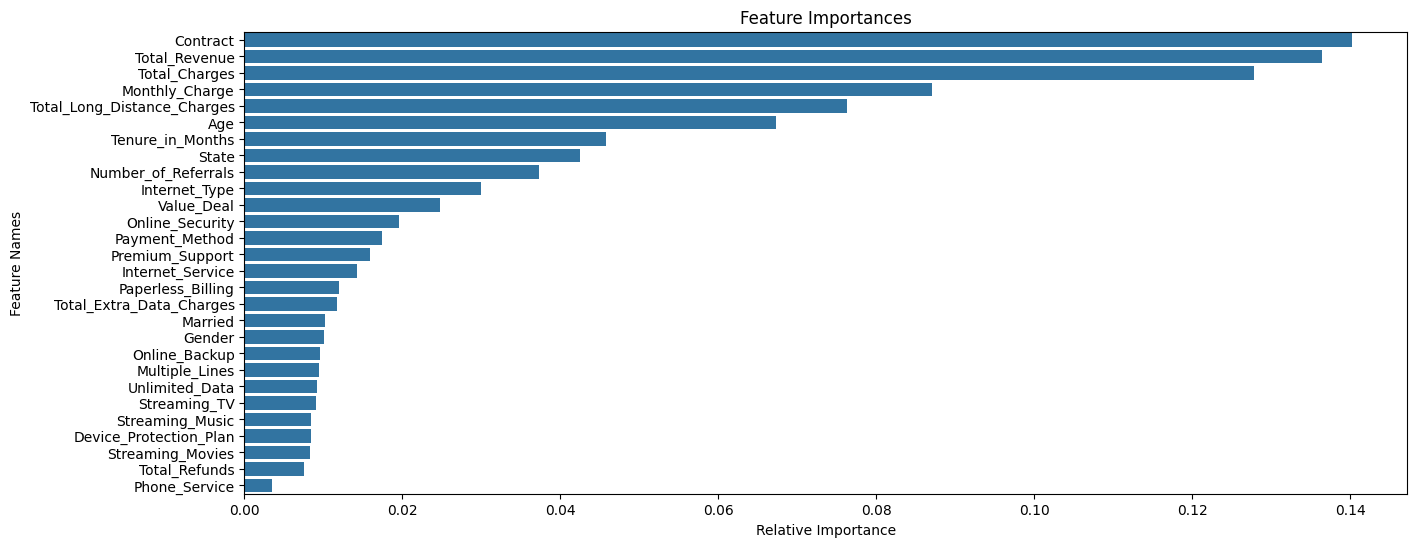

In [15]:
# Make predictions
y_pred = rf_model.predict(X_test)

# Evaluate the model
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Feature Selection using Feature Importance
importances = rf_model.feature_importances_
indices = np.argsort(importances)[::-1]

# Plot the feature importances
plt.figure(figsize=(15, 6))
sns.barplot(x=importances[indices], y=X.columns[indices])
plt.title('Feature Importances')
plt.xlabel('Relative Importance')
plt.ylabel('Feature Names')
plt.show()


In [31]:
# Predict on New Data

# Read the data from the specified sheet into a pandas DataFrame
new_data = pd.read_csv('/content/churn_dataset_300.csv')

# Display the first few rows of the fetched data
print(new_data.head())

# Retain the original DataFrame to preserve unencoded columns
original_data = new_data.copy()

# Retain the Customer_ID column
customer_ids = new_data['CustomerID']

# Drop columns that won't be used for prediction in the encoded DataFrame
new_data = new_data.drop(['CustomerID','Churn'], axis=1)

new_data_encoder = ['Gender','Partner','PhoneService','InternetService','ContractType ','PaymentMethod']
# Encode categorical variables using the saved label encoders
label_encoder = LabelEncoder()

for column in new_data_encoder:
    new_data[column] = label_encoder[column].transform(new_data[column])

# Make predictions
new_predictions = rf_model.predict(new_data)

# Add predictions to the original DataFrame
original_data['Customer_Status_Predicted'] = new_predictions

# Filter the DataFrame to include only records predicted as "Churned"
original_data = original_data[original_data['Customer_Status_Predicted'] == 1]

  CustomerID  Gender  SeniorCitizen Partner  Dependents  TenureMonths  \
0   CUST1001    Male              0     Yes           0            15   
1   CUST1002    Male              0     Yes           1            30   
2   CUST1003  Female              0     Yes           1            36   
3   CUST1004    Male              1     Yes           0            16   
4   CUST1005  Female              0     Yes           1            30   

  PhoneService InternetService    ContractType  PaymentMethod  MonthlyCharges  \
0          Yes     Fiber optic        One year   Mailed check           22.50   
1           No              No  Month-to-month    Credit card           70.54   
2           No     Fiber optic        One year    Credit card           35.55   
3           No     Fiber optic        One year  Bank transfer          117.31   
4          Yes             DSL        One year  Bank transfer          106.65   

   TotalCharges  SupportTickets  SatisfactionScore Churn  
0        337.50

TypeError: 'LabelEncoder' object is not subscriptable

In [28]:
new_data.columns

Index(['Gender', 'SeniorCitizen', 'Partner', 'Dependents', 'TenureMonths',
       'PhoneService', 'InternetService', 'ContractType', 'PaymentMethod',
       'MonthlyCharges', 'TotalCharges', 'SupportTickets',
       'SatisfactionScore'],
      dtype='object')

In [ ]:
new_data['']